# 1.采样数据

从指定的w = 1.477, b = 0.089中直接采样

In [58]:
import numpy as np

data = []
for i in range(100):  # 循环采样100点
    x = np.random.uniform(-10., 10.)  # 随机采样输入x
    # 采样高斯噪声
    eps = np.random.normal(0., 0.01)
    # 得到模型的输出
    y = 1.477 * x + 0.089 + eps
    data.append([x, y])
data = np.array(data)

# 2.计算误差

计算预测值与真实值

In [59]:
def mes(b, w, points):
    totalError = 0
    for i in range(0, len(points)):
        x = points[i, 0]
        y = points[i, 1]
        # 计算差的平方，并累加
        totalError += (y - (w * x + b)) ** 2
    return totalError / float(len(points))

# 3.计算梯度
公式推导...

In [60]:
def step_gradient(b_current, w_current, points, lr):
    b_gradient = 0
    w_gradient = 0
    M = float(len(points))  # 总样本数
    for i in range(len(points)):
        x = points[i, 0]
        y = points[i, 1]
        b_gradient += (2 * (w_current * x + b_current - y)) / M
        w_gradient += (2 * (w_current * x ** 2 + b_current * x - x * y)) / M
    new_b = b_current - b_gradient * lr
    new_w = w_current - w_gradient * lr
    return new_b, new_w

# 4.梯度更新

把对数据集的所有样本训练一次称为一个Epoch，共循环迭代num_iterations个Epoch。

In [61]:
def gradient_descent(points, starting_b, starting_w, lr, num_iterations):
    b = starting_b
    w = starting_w
    loss_rec = []
    for i in range(num_iterations):
        b, w = step_gradient(b, w, np.array(points), lr)
        loss = mes(b, w, points)
        loss_rec.append([loss, i])
        if i % 50 == 0:
            print(f'iterations={num_iterations},loss={loss},w={w},b={b}')
    return b, w, loss_rec

In [68]:
b, w, loss_rec = gradient_descent(data, 0, 0, 0.01, 50)

iterations=50,loss=10.548114997973265,w=0.8834137674122003,b=0.0007003405115862288


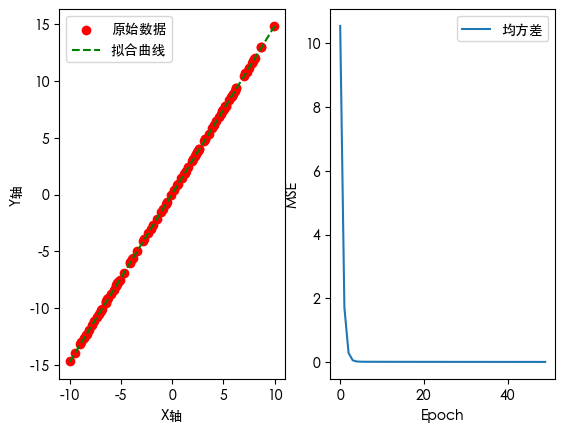

In [74]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Heiti TC']   # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False           # 解决负号显示问题
fig, axes = plt.subplots(1, 2)
axes[0].scatter(data[:, 0], data[:, 1], color='red', label='原始数据')
x = np.linspace(-10, 10, 100)
y = w * x + b
axes[0].plot(x, y, color='green', linestyle='--', label='拟合曲线')
axes[0].set_xlabel('X轴')
axes[0].set_ylabel('Y轴')
axes[0].legend()

loss_rec = np.array(loss_rec)
axes[1].plot(loss_rec[:, 1], loss_rec[:, 0], label='均方差')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend()

plt.show()